# Polynomial Regression:

- Polynomial regression is a method for modeling curvilinear relationships between variables by adding polynomial terms (like x^2, x^3) of the independent variable to a linear regression model.
- It allows the model to fit curves to data that doesn't fit a straight line.
- While it creates a non-linear relationship between the original independent and dependent variables, the model itself remains linear in terms of its parameters, allowing it to be solved using familiar linear regression techniques like ordinary least squares.


- How it Works:
    - Extend the Linear Model: A standard linear regression has the form y = β₀ + β₁x. Polynomial regression extends this by adding higher-degree terms of the independent variable x, such as:
y = β₀ + β₁x + β₂x² + β₃x³ + ... + βₙxⁿ.

    - Non-Linear Data: This extension allows the model to fit curved lines — for example, U-shaped or S-shaped patterns — which a simple straight line (linear regression) cannot capture.

    - Linear in Parameters: Even though the relationship between x and y is non-linear, the model is still linear in its coefficients (β₀, β₁, …, βₙ). You can treat each power of x (x, x², x³, etc.) as a separate independent variable.

    - Fit with Techniques: Since the model remains linear in its parameters, you can still use standard linear regression methods to find the best coefficient values (the βs) that fit the data.
 
- When to Use It:
    - Non-Linear Data: When the relationship between your dependent and independent variables is curved, not a straight line.
    - Complex Relationships: To capture more complex patterns that simple linear regression cannot. 

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

#### Example 1 (Synthetic Data):

In [16]:
# Creating X (Features) and y (Target) Variables:

X = 6 * np.random.rand(200,1) - 3

# y = 0.8X^2 + 0.9X + 2 + random noise
y = 0.8*(X**2) + 0.9 * X + 2 + np.random.randn(200,1)

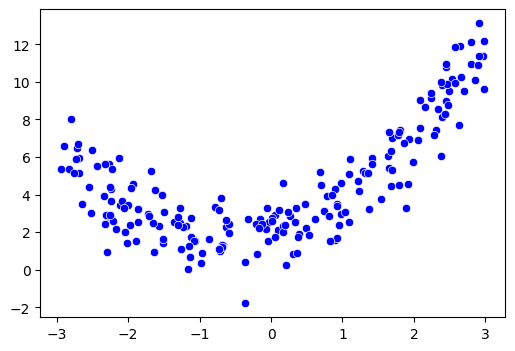

In [17]:
# Plotting X and y:

plt.figure(figsize = (6,4))
sns.scatterplot(x= X.ravel(), y= y.ravel(), color= 'blue')
plt.show()

In [18]:
# Train Test Split:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42)

In [19]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(160, 1)
(40, 1)
(160, 1)
(40, 1)


##### 1) Simple Linear Regression Model:

In [20]:
lr1 = LinearRegression()
lr1.fit(X_train, y_tra)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [21]:
# Predictions using Model:

y_pred = lr1.predict(X_test)

In [35]:
# Model Evaluation:

print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}')
print(f'R2-Score: {r2_score(y_test, y_pred)}')

RMSE: 2.5751345976049067
R2-Score: 0.4343654989283009


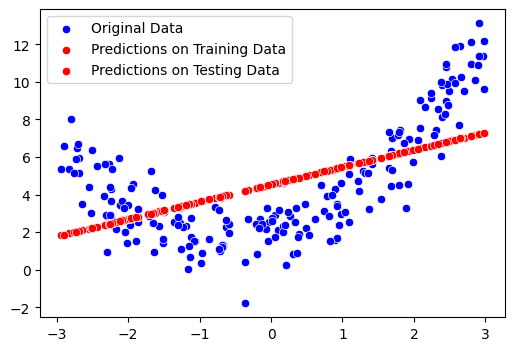

In [26]:
# Plotting Original Data (Full Data) vs Model Predictions:

plt.figure(figsize = (6,4))
sns.scatterplot(x= X.ravel(), y= y.ravel(), color= 'blue', label= 'Original Data')
sns.scatterplot(x= X_train.ravel(), y= lr1.predict(X_train).ravel(), color= 'red', label= 'Predictions on Training Data')
sns.scatterplot(x= X_test.ravel(), y= lr1.predict(X_test).ravel(), color= 'red', label= 'Predictions on Testing Data')
plt.show()

##### 2) Polynomial Regression Model:

**From Preprocessing, import PolynomialFeatures, which will help us transform our original data set by adding polynomial features**

We will go from the equation in the form (shown here as if we only had one x feature):

$$\hat{y} = \beta_0 + \beta_1x_1 + \epsilon $$

and create more features from the original x feature for some *d* degree of polynomial.

$$\hat{y} = \beta_0 + \beta_1x_1 + \beta_1x^2_1 +  ... + \beta_dx^d_1 + \epsilon$$

Then we can call the linear regression model on it, since in reality, we're just treating these new polynomial features x^2, x^3, ... x^d as new features. Obviously we need to be careful about choosing the correct value of *d* , the degree of the model. Our metric results on the test set will help us with this!

**The other thing to note here is we have multiple X features, not just a single one as in the formula above, so in reality, the PolynomialFeatures will also take *interaction* terms into account for example, if an input sample is two dimensional and of the form [a, b], the degree-2 polynomial features are [1, a, b, a^2, ab, b^2].**

In [28]:
# Creating Plynomial Features with Degree 2:

poly_features = PolynomialFeatures(degree= 2, include_bias= True)

In [30]:
# Turning Training and Test Data into Polynomial Features:

X_train_poly = poly_features.fit_transform(X_train)
X_test_poly = poly_features.transform(X_test)

In [33]:
print(X_train[0])
print(X_train_poly[0])

[1.92936781]
[1.         1.92936781 3.72246014]


In [34]:
# Polynomial Regression Model:

lr2 = LinearRegression()
lr2.fit(X_train_poly, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [37]:
# Predictions using Model:

y_pred = lr2.predict(X_test_poly)

In [38]:
# Model Evaluation:

print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}')
print(f'R2-Score: {r2_score(y_test, y_pred)}')

RMSE: 0.9019550341047983
R2-Score: 0.9306085763403393


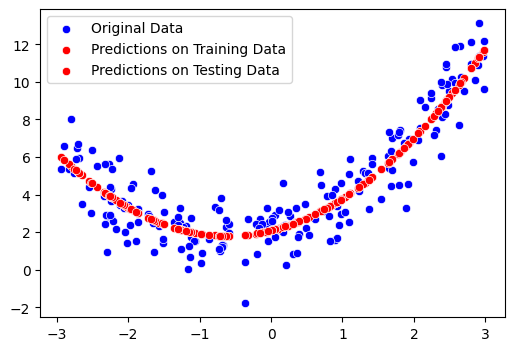

In [42]:
# Plotting Original Data (Full Data) vs Model Predictions:

plt.figure(figsize = (6,4))
sns.scatterplot(x= X.ravel(), y= y.ravel(), color= 'blue', label= 'Original Data')
sns.scatterplot(x= X_train.ravel(), y= lr2.predict(X_train_poly).ravel(), color= 'red', label= 'Predictions on Training Data')
sns.scatterplot(x= X_test.ravel(), y= lr2.predict(X_test_poly).ravel(), color= 'red', label= 'Predictions on Testing Data')
plt.show()